In [1]:
import sys, os
import glob
import json
import random

os.environ["TORCH_COMPILE_DISABLE"] = "1"

import torch
torch.set_default_dtype(torch.float64)
torch.set_default_device('cuda:0')
torch.set_printoptions(precision=8)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import openmm.app as app

sys.path.insert(0, '..')
from cmm.ffxml import ForceFieldXML
from cmm.units import HARTREE2KCAL
from cmm.develop.data import EdaData, EspData, DipoleData, PolarizabilityData, slice_data
from cmm.develop.optimize import Trainer, Optimizer
from cmm.develop.metrics import plot_correlation, plot_eda_scan
from cmm.develop.report import report_eda_cluster, report_dipos, report_esp

In [3]:
eda_datas = [
    # EdaData.from_files('dimers/water_water/struct.pdb', glob.glob('dimers/water_water/thg_scan/*/eda.out')),
    EdaData.from_files('dimers/water_water/struct.pdb', glob.glob('dimers/water_water/water_dimer_cluster/*/eda.out')),
    # EdaData.from_files('dimers/water_water/struct.pdb', glob.glob('dimers/water_water/water_dimer_cluster/*/eda.out')),
]

2025-10-08 13:51:30,144 - INFO - The following parameters are being optimized: 
PauliRepulsion/Pauli/q_pauli
2025-10-08 13:51:30,145 - INFO - The following parameters are enforced to be positive during optimization: 
PauliRepulsion/Pauli/q_pauli


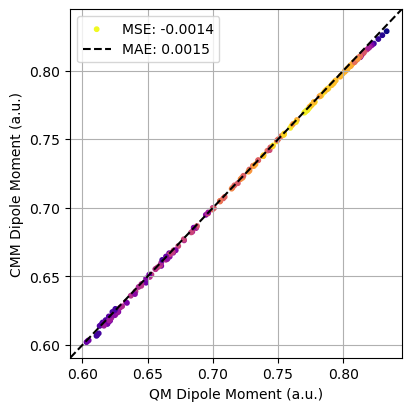

In [11]:
dipo_datas = [
    DipoleData.from_files('monomers/water/monomer.pdb', glob.glob('monomers/water/04.qchem/*/qchem.out')),
]

ff = ForceFieldXML('/pscratch/sd/e/eric6/pycmm-dev/scripts/water_refit.xml', requires_grad=True)

optimizer = Optimizer(
    ff,
    freeze_water=False,
    opt_params=[
        # 'Z', 'b_elec', 'q20', 'q21c', 'q21s', 'q22c', 'q22s',
        # 'b_xpol', 'q_xpol', 'Kdipo_xpol', 'Kquad_xpol', 
        "q_pauli",
        # 'alpha_xx', 'alpha_yy', 'alpha_zz', 'eta'
    ],
    optim='adam',
    lr=0.001,
    l2=1.0,
    l2_params=["q_pauli"],
    additional_positive_constraints=['']
)

trainer = Trainer(
    ff, 
    optimizer, 
    target_weights={'PolarizabilityData': 1e4, 'EdaData':10, 'EspData': 2e6},
    eda_weights={'perm_elec': 0.0, 'total': 0.0, 'pauli': 10.0, 'disp': 0.0, 'pol': 0.0, 'ct': 0.0},
    # weight_func=None
)

report_dipos(trainer, dipo_datas[0])

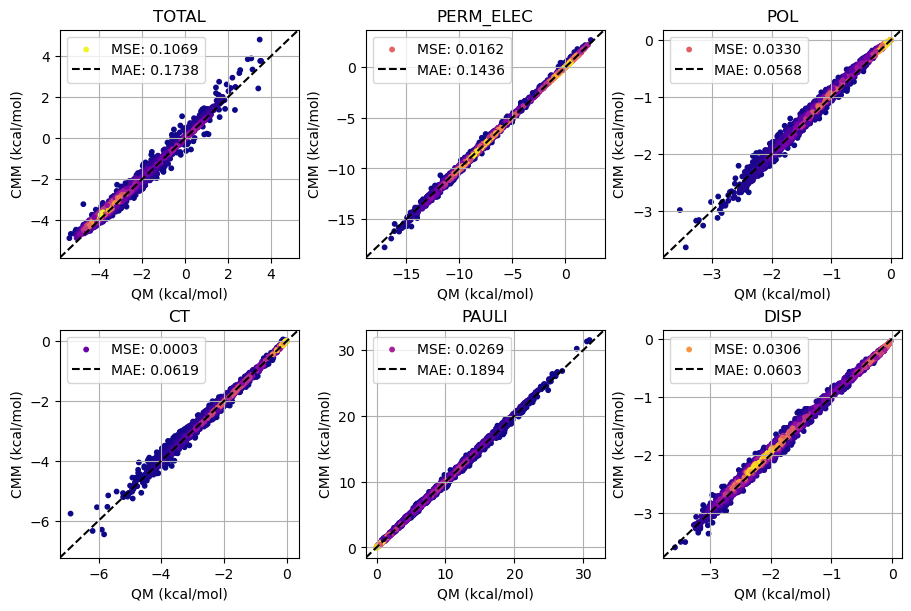

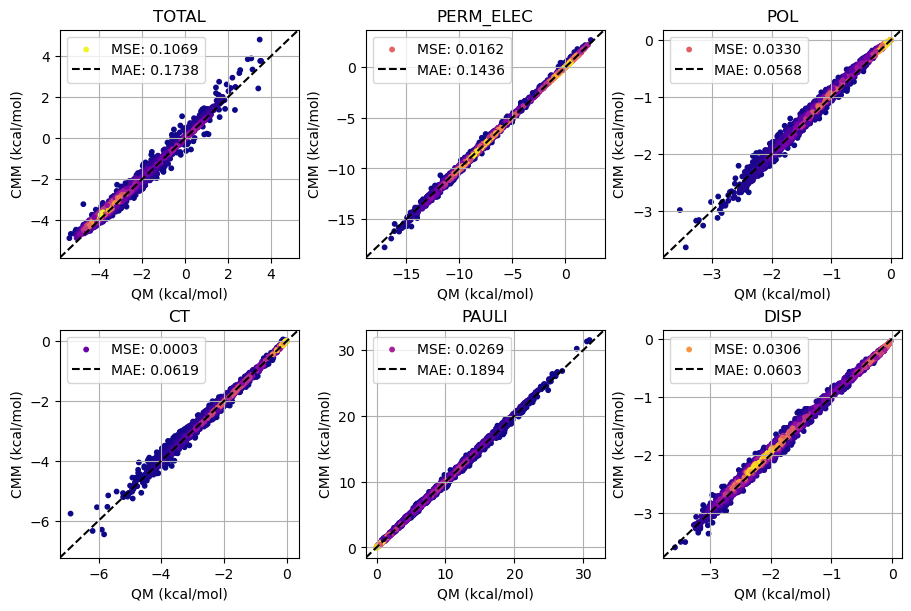

In [12]:
report_eda_cluster(trainer, eda_datas[0])

In [13]:
trainer.train(eda_datas, 10)

0 EdaData {'perm_elec': 0.038664792913618455, 'pauli': 0.07015285961568943, 'ct': 0.009825417009727467, 'pol': 0.0057215251086838274, 'disp': 0.005634394063821304, 'total': 0.05074863935219272}
1 EdaData {'perm_elec': 0.038664792913618455, 'pauli': 0.06915875744311306, 'ct': 0.009825417009727465, 'pol': 0.005721525108683828, 'disp': 0.005634394063821304, 'total': 0.049599996096534794}
2 EdaData {'perm_elec': 0.038664792913618455, 'pauli': 0.0684887901813494, 'ct': 0.009825417009727465, 'pol': 0.005721525108683829, 'disp': 0.005634394063821304, 'total': 0.04877858335355622}
3 EdaData {'perm_elec': 0.038664792913618455, 'pauli': 0.06812955894089116, 'ct': 0.009825417009727465, 'pol': 0.005721525108683829, 'disp': 0.005634394063821304, 'total': 0.048274975950164244}
4 EdaData {'perm_elec': 0.038664792913618455, 'pauli': 0.06803674725063058, 'ct': 0.009825417009727465, 'pol': 0.005721525108683828, 'disp': 0.005634394063821304, 'total': 0.04805093734497795}
5 EdaData {'perm_elec': 0.0386647

[[{'perm_elec': 0.038664792913618455,
   'pauli': 0.07015285961568943,
   'ct': 0.009825417009727467,
   'pol': 0.0057215251086838274,
   'disp': 0.005634394063821304,
   'total': 0.05074863935219272},
  {'perm_elec': 0.038664792913618455,
   'pauli': 0.06915875744311306,
   'ct': 0.009825417009727465,
   'pol': 0.005721525108683828,
   'disp': 0.005634394063821304,
   'total': 0.049599996096534794},
  {'perm_elec': 0.038664792913618455,
   'pauli': 0.0684887901813494,
   'ct': 0.009825417009727465,
   'pol': 0.005721525108683829,
   'disp': 0.005634394063821304,
   'total': 0.04877858335355622},
  {'perm_elec': 0.038664792913618455,
   'pauli': 0.06812955894089116,
   'ct': 0.009825417009727465,
   'pol': 0.005721525108683829,
   'disp': 0.005634394063821304,
   'total': 0.048274975950164244},
  {'perm_elec': 0.038664792913618455,
   'pauli': 0.06803674725063058,
   'ct': 0.009825417009727465,
   'pol': 0.005721525108683828,
   'disp': 0.005634394063821304,
   'total': 0.0480509373449

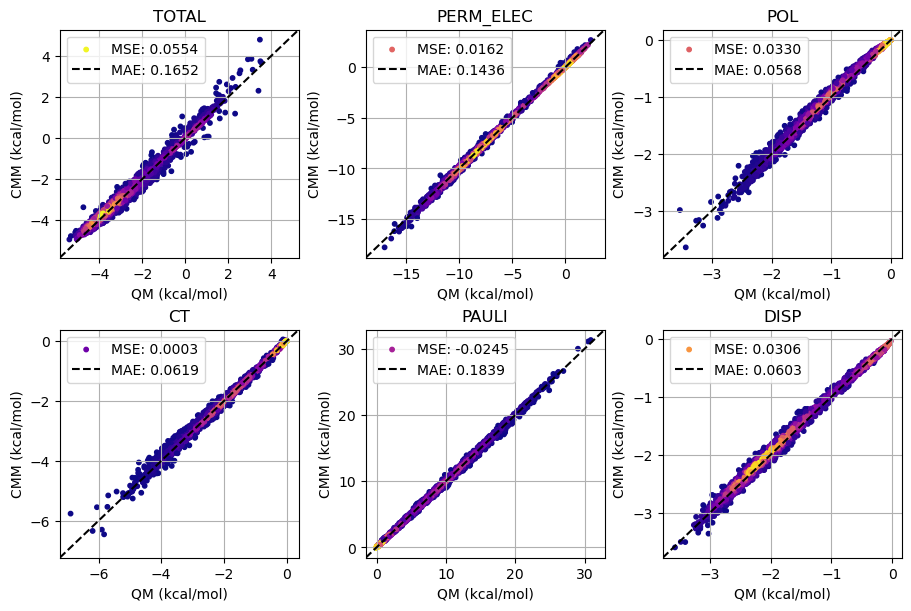

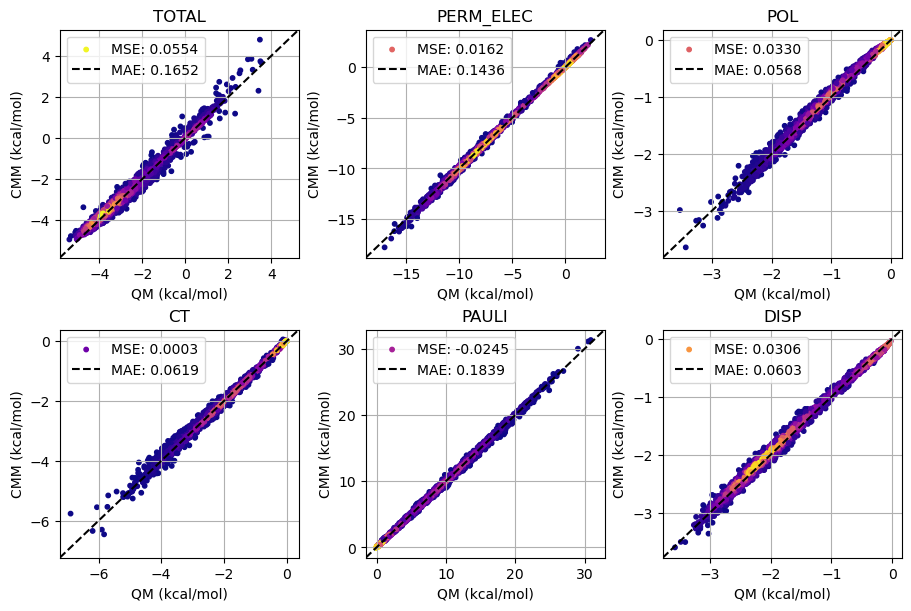

In [14]:
report_eda_cluster(trainer, eda_datas[0])

In [ ]:
ff.save("test.xml")